In [1]:
from pathlib import Path 
import sys
import ProbabilisticParcellation.util as ut
import ProbabilisticParcellation.individ_group as ig
import ProbabilisticParcellation.plot as ppp
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
import numpy as np
import scipy.stats as ss



/Users/callithrix/code/Python/IndividualParcellation/env/lib/python3.9/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)


## Individual vs. group analysis

In [2]:
# To produce the individual-group evaluation results:
mname = 'Models_03/NettekovenSym32_space-MNISymC2'
fname = ut.model_dir+ f'/Models/Evaluation_03/indivgroup_{mname.split("/")[1].split("_space")[0]}_rest-rerun.tsv'
reproduce_result = False

if reproduce_result:
    info,model = ut.load_batch_best(mname)
    Uhat_data,Uhat_complete,Uhat_group = ig.get_individ_group_mdtb(model,atlas='MNISymC2')
    D = ig.evaluate_dcbc(Uhat_data,Uhat_complete,Uhat_group,atlas='MNISymC2')
    # Save as a tsv file
    D.to_csv(fname,sep='\t', index=False)
else:
    D = pd.read_csv(fname, sep='\t')

D['data'] = 'rest'

In [3]:
# To get the individual-group task evaluation results:
mname = 'Models_03/NettekovenSym32_space-MNISymC2'
fname = ut.model_dir+ f'/Models/Evaluation_03/indivgroup_{mname.split("/")[1].split("_space")[0]}.tsv'
T = pd.read_csv(fname, sep='\t')
T['data'] = 'task'

In [4]:
# Concatenate
Data = pd.concat([D,T])
Data[(Data.runs==1)]

,Unnamed: 0,type,runs,dcbc,subject,data
1,0,data,1,0.011057,1,rest
2,0,data and group,1,0.025330,1,rest
6,0,data,1,0.031133,2,rest
7,0,data and group,1,0.040331,2,rest
11,0,data,1,0.040523,4,rest
...,...,...,...,...,...,...
695,0,data and group,1,0.072803,22,task
727,0,data,1,0.062522,23,task
728,0,data and group,1,0.083603,23,task
760,0,data,1,0.092360,24,task


### Load results and plot Figure

In [9]:
def plot_eval_rest(D,normalize=True,var='dcbc'):
    plt.figure(figsize=(5,4))
    gm = D[var][D.type=='group'].mean()
    ## Subtract the value of 'group' from the individual dcbc values
    if normalize:
        A=pd.pivot_table(D[D.type=='group'],values=var,index='subject')
        baseline = A.loc[D.subject,var].values 
        D[var]=D[var]-baseline+gm
    sb.lineplot(data=D[D.type!='group'],y=var,x='runs',
                hue='data', 
                errorbar='se',
                style='type',
                markers=True, dashes=False)
    sb.despine()
    runs = np.arange(16,dtype=int)+1
    labels = [f'{i*10}' if (i==1 or i%4==0) else '' for i in runs]

    plt.xticks(ticks=runs,labels=labels)
    plt.xlabel('Functional localizer [min]')
    plt.axhline(gm,color='b',ls=':')

In [6]:
Data.groupby(['type','data', 'subject', 'runs']).mean()
Data[Data.subject!=1 & (Data.subject!=2)]

Unnamed: 0      dcbc
type  data subject runs                      
data  rest 1       1            0.0  0.011057
                   2            0.0  0.015705
           2       1            0.0  0.031133
                   2            0.0  0.010893
           4       1            0.0  0.040523
...                             ...       ...
group task 20      0            0.0  0.084423
           21      0            0.0  0.145962
           22      0            0.0  0.074286
           23      0            0.0  0.047193
           24      0            0.0  0.106937

[877 rows x 2 columns]

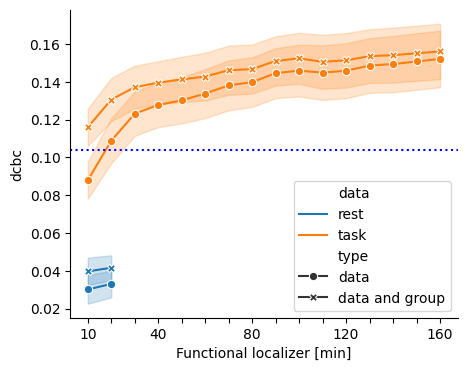

In [11]:
plot_eval_rest(Data,normalize=True,var='dcbc')


/var/folders/y1/13zjm1t50ms6ds24c69y7vx40000gn/T/ipykernel_10082/3368206795.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  D[var]=D[var]-baseline+gm


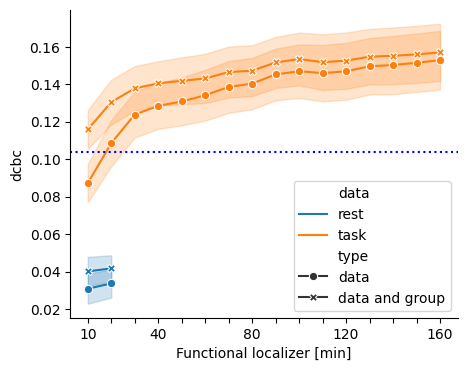

In [13]:
plot_eval_rest(Data[Data.subject!=1 | (Data.subject!=2)],normalize=True,var='dcbc')
# plt.savefig(ut.figure_dir + 'individgroup_dcbc_NettekovenSym32_task_vs_rest-rerun.pdf',bbox_inches='tight')

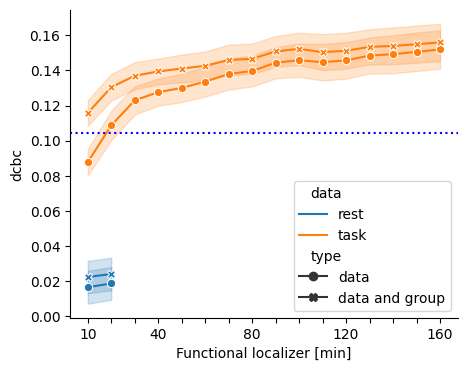

In [14]:
plot_eval_rest(Data,normalize=True,var='dcbc')
plt.savefig(ut.figure_dir + 'individgroup_dcbc_NettekovenSym32_task_vs_rest.pdf',bbox_inches='tight')

### Do reported stats
How much individual data do we need to be (with data alone) better than the group atlas?

In [56]:
D = pd.read_csv(ut.model_dir + '/Models/Evaluation_03/indivgroup_NettekovenSym32.tsv',sep='\t')
T = pd.pivot_table(D[(D.runs==0) | (D.runs==4)],index='subject',columns='type',values='dcbc')
tres = ss.ttest_rel(T['data'],T['group'])
print(f'40 min data vs. group t(23)={tres.statistic:.3f}, p = {tres.pvalue:.4f}')


40 min data vs. group t(23)=2.981, p = 0.0067


In [48]:
# 20 min combined vs. data / group (note combined vs. group not quite significant for 10min)
T = pd.pivot_table(D[(D.runs==0) | (D.runs==2)],index='subject',columns='type',values='dcbc')
tres = ss.ttest_rel(T['data and group'],T['data'])
print(f'20 min combined vs. data t(23)={tres.statistic:.3f}, p = {tres.pvalue}')
tres = ss.ttest_rel(T['data and group'],T['group'])
print(f'20 min combined vs. group t(23)={tres.statistic:.3f}, p = {tres.pvalue:.4f}')

20 min combined vs. data t(23)=11.468, p = 5.433631836442057e-11
20 min combined vs. group t(23)=3.395, p = 0.0025


In [9]:
# 20 min combined vs. data / group (note combined vs. group not quite significant for 10min)
T = pd.pivot_table(D[(D.runs==0) | (D.runs==16)],index='subject',columns='type',values='dcbc')
tres = ss.ttest_rel(T['data and group'],T['data'])
print(f'160 min combined vs. data t(23)={tres.statistic:.3f}, p = {tres.pvalue}')

160 min combined vs. data t(23)=5.838, p = 5.98956560470188e-06


## Cosine error

In [11]:
# To produce the individual-group cosine error evaluation results:
mname = 'Models_03/NettekovenSym32_space-MNISymC2'
# mname = 'Models_03/asym_Md_space-MNISymC3_K-17'
fname = ut.model_dir+ f'/Models/Evaluation_03/indivgroup_coserr_{mname.split("/")[1].split("_space")[0]}.tsv'
reproduce_result = False

if reproduce_result:
    info,model = ut.load_batch_best(mname)
    Uhat_data,Uhat_complete,Uhat_group = ig.get_individ_group_mdtb(model,atlas='MNISymC2')
    D = ig.evaluate_coserr(model,Uhat_data,Uhat_complete,Uhat_group,atlas='MNISymC2', soft_assign=False)
    # Save as a tsv file
    D.to_csv(fname,sep='\t', index=False)
else:
    D = pd.read_csv(fname, sep='\t')

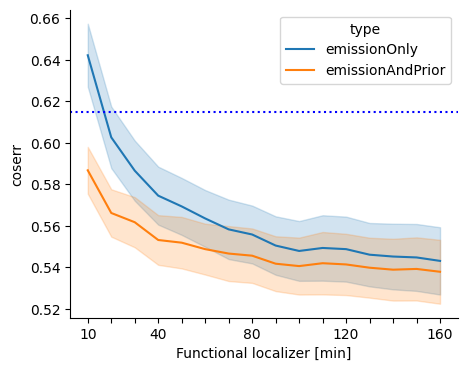

In [11]:
ig.plot_eval('indivgroup_coserr_hard_NettekovenSym32.tsv', var='coserr')
plt.savefig(ut.figure_dir + 'individgroup_coserr_hard_NettekovenSym32.pdf',bbox_inches='tight')

In [50]:
Dcos = pd.read_csv(ut.model_dir + '/Models/Evaluation_03/indivgroup_coserr_hard_NettekovenSym32.tsv',sep='\t')
# Rename levels of Dcos type
rename = {'emissionOnly':'data', 'emissionAndPrior':'data and group'}
Dcos['type'] = Dcos['type'].replace(rename)

Cos = pd.pivot_table(Dcos[(Dcos.runs==0) | (Dcos.runs==3)],index='subject',columns='type',values='coserr')
tres = ss.ttest_rel(Cos['data'],Cos['group'])
print(f'30 min data vs. group t(23)={tres.statistic:.3f}, p = {tres.pvalue:.4f}')

Cos = pd.pivot_table(Dcos[(Dcos.runs==0) | (Dcos.runs==4)],index='subject',columns='type',values='coserr')
tres = ss.ttest_rel(Cos['data'],Cos['group'])
print(f'40 min data vs. group t(23)={tres.statistic:.3f}, p = {tres.pvalue:.4f}')

30 min data vs. group t(23)=-1.934, p = 0.0655
40 min data vs. group t(23)=-2.869, p = 0.0087


In [57]:
# 10 min combined vs. data / group
Cos = pd.pivot_table(Dcos[(Dcos.runs==0) | (Dcos.runs==2)],index='subject',columns='type',values='coserr')
tres = ss.ttest_rel(Cos['data and group'],Cos['data'])
print(f'10 min combined vs. data t(23)={tres.statistic:.3f}, p = {tres.pvalue}')
tres = ss.ttest_rel(Cos['data and group'],Cos['group'])
print(f'10 min combined vs. group t(23)={tres.statistic:.3f}, p = {tres.pvalue:.4f}')


10 min combined vs. data t(23)=-9.098, p = 4.41408339070074e-09
10 min combined vs. group t(23)=-4.241, p = 0.0003


In [54]:
# 160 min combined vs. data / group (note combined vs. group not quite significant for 10min)
Cos = pd.pivot_table(Dcos[(Dcos.runs==0) | (Dcos.runs==16)],index='subject',columns='type',values='coserr')
tres = ss.ttest_rel(Cos['data and group'],Cos['data'])
print(f'160 min combined vs. data t(23)={tres.statistic:.3f}, p = {tres.pvalue}')

160 min combined vs. data t(23)=-3.798, p = 0.0009288483018179889


## Appendix: Individual group for other parcellations

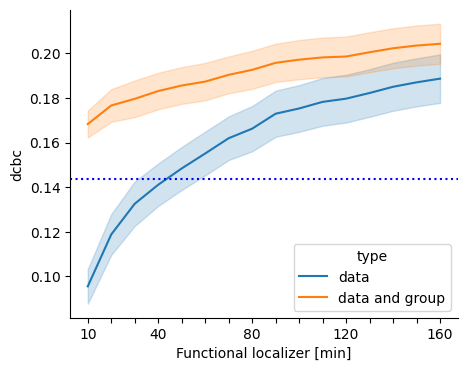

In [12]:
ig.plot_eval('indivgroup_asym_Md_K17.tsv')
# t.ylim([0.21,0.3])


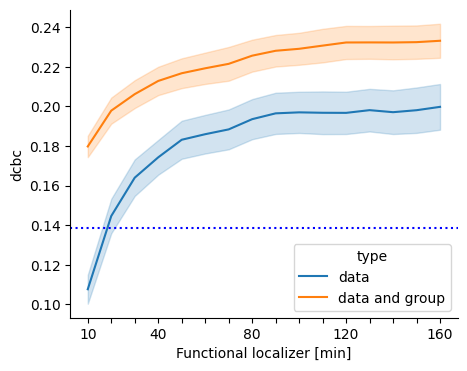

In [13]:
ig.plot_eval('indivgroup_asym_Md_K68.tsv')

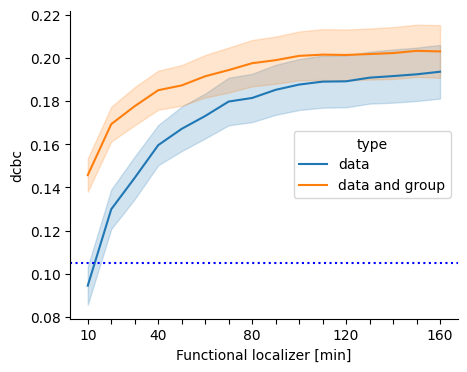

In [14]:
ig.plot_eval('indivgroup_asym_MdPoNiIbWmDeSo_K68.tsv')

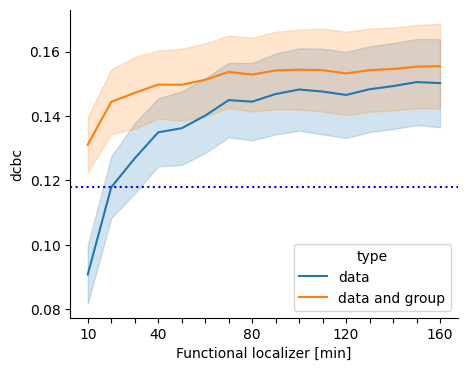

In [15]:
ig.plot_eval('indivgroup_sym_MdPoNiIbWmDeSo_K68.tsv',normalize=True)